In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
metadata = pd.read_excel('../data/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')
data = pd.read_csv('../datasets/rgi_annotation_all_bins.tsv', sep = '\t')

In [3]:
data.columns

Index(['ORF_ID', 'Contig', 'Start', 'Stop', 'Orientation', 'Cut_Off',
       'Pass_Bitscore', 'Best_Hit_Bitscore', 'Best_Hit_ARO', 'Best_Identities',
       'ARO', 'Model_type', 'SNPs_in_Best_Hit_ARO', 'Other_SNPs', 'Drug Class',
       'Resistance Mechanism', 'AMR Gene Family', 'Predicted_DNA',
       'Predicted_Protein', 'CARD_Protein_Sequence',
       'Percentage Length of Reference Sequence', 'ID', 'Model_ID', 'Nudged',
       'Note', 'Hit_Start', 'Hit_End', 'Antibiotic', 'Sample', 'BIN',
       'Species'],
      dtype='object')

In [59]:
# data.to_csv('resistance.csv', index = False)

In [5]:
data['Antibiotic']

0                                              vancomycin
1                                              vancomycin
2       tetracycline; doxycycline; minocycline; chlort...
3       erythromycin; roxithromycin; lincomycin; telit...
4                                            tetracycline
                              ...                        
7438                                           vancomycin
7439                                           vancomycin
7440                                           vancomycin
7441                                           vancomycin
7442                                           vancomycin
Name: Antibiotic, Length: 7443, dtype: object

In [6]:
data_strict = data[data['Cut_Off'] == 'Strict']

In [32]:
data_strict.columns

Index(['ORF_ID', 'Contig', 'Start', 'Stop', 'Orientation', 'Cut_Off',
       'Pass_Bitscore', 'Best_Hit_Bitscore', 'Best_Hit_ARO', 'Best_Identities',
       'ARO', 'Model_type', 'SNPs_in_Best_Hit_ARO', 'Other_SNPs', 'Drug Class',
       'Resistance Mechanism', 'AMR Gene Family', 'Predicted_DNA',
       'Predicted_Protein', 'CARD_Protein_Sequence',
       'Percentage Length of Reference Sequence', 'ID', 'Model_ID', 'Nudged',
       'Note', 'Hit_Start', 'Hit_End', 'Antibiotic', 'Sample', 'BIN',
       'Species'],
      dtype='object')

In [7]:
antibiotics_set = set()
for antibiotics in list(data_strict['Antibiotic']):
    # print(antibiotics)
    try:
        for antibiotic in antibiotics.split('; '):
            antibiotics_set.add(antibiotic)
    except:
        continue
        # antibiotics_set.add(antibiotic)
    

In [8]:
len(antibiotics_set)

130

In [64]:
data.columns

Index(['ORF_ID', 'Contig', 'Start', 'Stop', 'Orientation', 'Cut_Off',
       'Pass_Bitscore', 'Best_Hit_Bitscore', 'Best_Hit_ARO', 'Best_Identities',
       'ARO', 'Model_type', 'SNPs_in_Best_Hit_ARO', 'Other_SNPs', 'Drug Class',
       'Resistance Mechanism', 'AMR Gene Family', 'Predicted_DNA',
       'Predicted_Protein', 'CARD_Protein_Sequence',
       'Percentage Length of Reference Sequence', 'ID', 'Model_ID', 'Nudged',
       'Note', 'Hit_Start', 'Hit_End', 'Antibiotic', 'Sample', 'BIN',
       'Species'],
      dtype='object')

In [65]:
data_strict['Resistance Mechanism'].unique()

array(['antibiotic target alteration', 'antibiotic target protection',
       'antibiotic efflux', 'antibiotic inactivation',
       'antibiotic target alteration; antibiotic efflux',
       'antibiotic target alteration; antibiotic efflux; reduced permeability to antibiotic',
       'antibiotic target alteration; antibiotic target replacement',
       'antibiotic target replacement',
       'antibiotic efflux; reduced permeability to antibiotic',
       'reduced permeability to antibiotic'], dtype=object)

In [9]:
data_final = {}

In [10]:
for antibiotic in antibiotics_set:
    for sample in list(data_strict['Sample'].unique()):
        if sample not in data_final:
            data_final[sample] = set()
        for anti in list(data_strict[data_strict['Sample'] == sample]['Antibiotic']):
        # for anti in list(data_strict[data_strict['Sample'] == sample]['Resistance Mechanism']):
            try:
                if antibiotic in anti.split('; '):
                    data_final[sample].add(antibiotic)
            except:
                continue
                

In [11]:
data_final

{'37035_7#10': {'azithromycin',
  'chlortetracycline',
  'clarithromycin',
  'clindamycin',
  'dalfopristin',
  'demeclocycline',
  'dirithromycin',
  'doxycycline',
  'erythromycin',
  'griseoviridin',
  'lincomycin',
  'madumycin II',
  'minocycline',
  'oleandomycin',
  'ostreogrycin B3',
  'oxytetracycline',
  'patricin A',
  'patricin B',
  'pristinamycin IA',
  'pristinamycin IB',
  'pristinamycin IC',
  'quinupristin',
  'roxithromycin',
  'spiramycin',
  'teicoplanin',
  'telithromycin',
  'tetracycline',
  'tylosin',
  'vancomycin',
  'vernamycin C',
  'virginiamycin M1',
  'virginiamycin S2'},
 '37035_2#13': {'amikacin',
  'azithromycin',
  'benzalkonium chloride',
  'butirosin',
  'chlortetracycline',
  'clarithromycin',
  'clindamycin',
  'dalfopristin',
  'demeclocycline',
  'dirithromycin',
  'doxycycline',
  'erythromycin',
  'gentamicin',
  'gentamicin B',
  'griseoviridin',
  'isepamicin',
  'kanamycin A',
  'lincomycin',
  'lividomycin',
  'madumycin II',
  'metronida

In [12]:
# build a list of (sample, antibiotic) pairs
rows = []
for sample, antibiotics in data_final.items():
    for ab in antibiotics:
        rows.append((sample, ab))

# create a DataFrame from those pairs
df = pd.DataFrame(rows, columns=['sample', 'antibiotic'])

# pivot to wide format with presence (1/0)
presence_df = (
    df.assign(presence=1)
      .pivot_table(index='antibiotic', columns='sample', values='presence', fill_value=0)
      .astype(int)
)

presence_df

sample,36703_3#1,36703_3#10,36703_3#12,36703_3#13,36703_3#14,36703_3#15,36703_3#16,36703_3#17,36703_3#18,36703_3#19,...,37082_3#3,37082_3#30,37082_3#31,37082_3#32,37082_3#4,37082_3#5,37082_3#6,37082_3#7,37082_3#8,37082_3#9
antibiotic,,,,,,,,,,,,,,,,,,,,,
2'-N-ethylnetilmicin,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5-episisomicin,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
acriflavine,0,0,1,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,1
amikacin,0,0,1,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,1
amoxicillin,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tylosin,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
vancomycin,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
vernamycin C,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
rare = ['37082_3#16',
'37082_2#4',
'37035_2#22',
'37035_7#18',
'36703_3#20',
'36703_3#4']

In [14]:
presence_df = presence_df[[x for x in presence_df.columns if x not in rare]]

In [15]:
presence_df.head()

sample,36703_3#1,36703_3#10,36703_3#12,36703_3#13,36703_3#14,36703_3#15,36703_3#16,36703_3#17,36703_3#18,36703_3#19,...,37082_3#3,37082_3#30,37082_3#31,37082_3#32,37082_3#4,37082_3#5,37082_3#6,37082_3#7,37082_3#8,37082_3#9
antibiotic,,,,,,,,,,,,,,,,,,,,,
2'-N-ethylnetilmicin,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5-episisomicin,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
acriflavine,0,0,1,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,1
amikacin,0,0,1,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,1
amoxicillin,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
presence_df.index

Index(['2'-N-ethylnetilmicin', '5-episisomicin', 'acriflavine', 'amikacin',
       'amoxicillin', 'ampicillin', 'azidamfenicol', 'azithromycin',
       'bacitracin', 'bacitracin A',
       ...
       'tigecycline', 'tobramycin', 'triclosan', 'trimethoprim',
       'trovafloxacin', 'tylosin', 'vancomycin', 'vernamycin C',
       'virginiamycin M1', 'virginiamycin S2'],
      dtype='object', name='antibiotic', length=130)

In [17]:
presence_df = presence_df.T

In [18]:
labels = []
for item in presence_df.index:
    labels.append(metadata[metadata['Lane'] == item]['Lifestyle'].iloc[0])

In [19]:
presence_df['label'] = labels

In [20]:
presence_df

antibiotic,2'-N-ethylnetilmicin,5-episisomicin,acriflavine,amikacin,amoxicillin,ampicillin,azidamfenicol,azithromycin,bacitracin,bacitracin A,...,tobramycin,triclosan,trimethoprim,trovafloxacin,tylosin,vancomycin,vernamycin C,virginiamycin M1,virginiamycin S2,label
sample,,,,,,,,,,,,,,,,,,,,,
36703_3#1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,Urban
36703_3#10,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,1,1,1,1,Urban
36703_3#12,0,0,1,1,0,1,0,1,0,0,...,1,1,1,0,0,1,0,0,0,Rural
36703_3#13,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,Rural
36703_3#14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,Rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,Rural
37082_3#6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,Rural
37082_3#7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,Rural


In [21]:
from scipy.stats import chi2_contingency, fisher_exact

In [23]:
features_to_test = [col for col in presence_df.columns if col != 'label']

# Lista para guardar los resultados
results = []

# --- 3. Iterar y Probar ---
print("Ejecutando pruebas...\n")
for feature in features_to_test:
    
    # (a) Crear la tabla de contingencia 2x2
    # Esto cuenta las combinaciones de [Grupo] vs [Presencia/Ausencia]
    contingency_table = pd.crosstab(presence_df['label'], presence_df[feature])
    
    # Opcional: imprimir la tabla para verificar
    # print(f"--- Tabla para {feature} ---")
    # print(contingency_table)
    # print("\n")

    # (b) Aplicar la prueba Chi-cuadrada
    # g, p, dof, exp = chi2_contingency(contingency_table)
    # Nota: Usamos 'correction=True' (Corrección de Yates) que es más 
    # conservadora y recomendada para tablas 2x2.
    try:
        chi2, p_chi2, dof, expected = chi2_contingency(contingency_table, correction=True)
        
        # (c) [RECOMENDADO] Aplicar la Prueba Exacta de Fisher
        # Es más precisa para conteos bajos.
        odds_ratio, p_fisher = fisher_exact(contingency_table)

        # (d) Guardar resultados
        results.append({
            'feature': feature,
            'chi2_stat': chi2,
            'p_value_chi2': p_chi2,
            'p_value_fisher': p_fisher
        })
    except ValueError as e:
        # Esto puede pasar si una columna es toda 0s o toda 1s
        print(f"No se pudo calcular la prueba para {feature}: {e}")
        results.append({
            'feature': feature,
            'chi2_stat': None,
            'p_value_chi2': None,
            'p_value_fisher': None
        })


# --- 4. Ver Resultados ---
# Convertir la lista de resultados en un DataFrame limpio
results_df = pd.DataFrame(results)
results_df

Ejecutando pruebas...

No se pudo calcular la prueba para vancomycin: The input `table` must be of shape (2, 2).


,feature,chi2_stat,p_value_chi2,p_value_fisher
0,2'-N-ethylnetilmicin,0.000000,1.000000e+00,1.000000e+00
1,5-episisomicin,0.000000,1.000000e+00,1.000000e+00
2,acriflavine,0.983259,3.213956e-01,3.118158e-01
3,amikacin,0.045018,8.319709e-01,6.983009e-01
4,amoxicillin,0.037640,8.461674e-01,4.050000e-01
...,...,...,...,...
125,tylosin,48.914264,2.673991e-12,5.393307e-13
126,vancomycin,NaN,NaN,NaN
127,vernamycin C,48.914264,2.673991e-12,5.393307e-13
128,virginiamycin M1,48.914264,2.673991e-12,5.393307e-13


C:\Users\rafap\AppData\Local\Temp\ipykernel_16024\3041855406.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


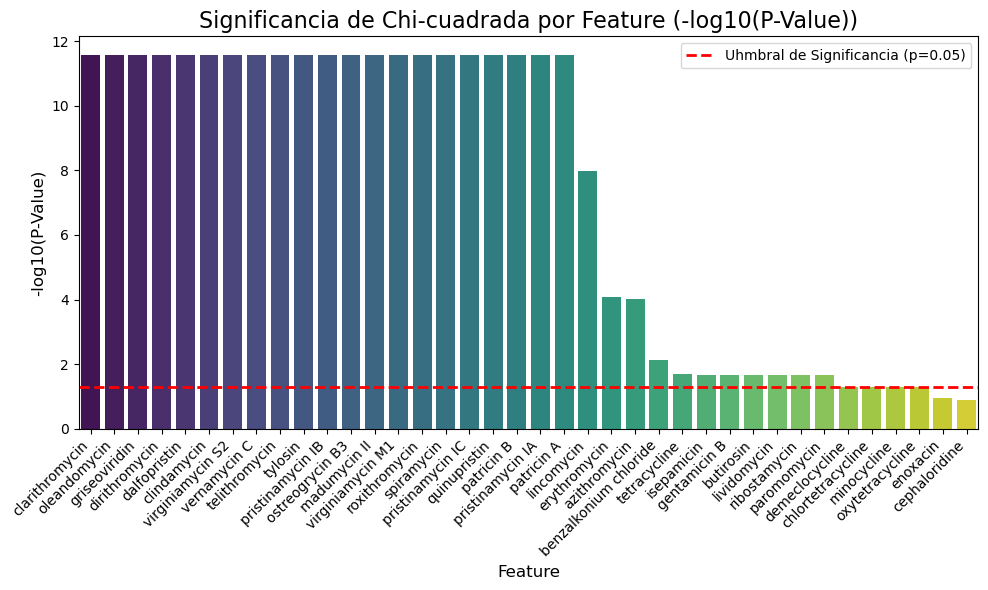

In [44]:

results_aux = results_df[results_df['p_value_chi2'] < 0.15]
plot_df = results_aux.dropna(subset=['p_value_chi2']).copy()

# Definimos el umbral de significancia
p_threshold = 0.05

plot_df = results_aux.dropna(subset=['p_value_chi2']).copy()

# Manejar p-values de 0: reemplazarlos por el número más pequeño posible
# Esto es crucial para que -log10 no dé infinito
plot_df.loc[plot_df['p_value_chi2'] == 0, 'p_value_chi2'] = np.finfo(float).eps

# Calculamos el -log10(p)
plot_df['neg_log10_p_chi2'] = -np.log10(plot_df['p_value_chi2'])

# Definimos el umbral de significancia (p=0.05)
p_threshold = 0.05
log_threshold = -np.log10(p_threshold)

# Ordenamos las barras por el valor -log10(p) (de más a menos significativo)
plot_df_sorted = plot_df.sort_values('neg_log10_p_chi2', ascending=False)


# --- 3. Crear el Gráfico ---
plt.figure(figsize=(10, 6))

barplot = sns.barplot(
    x='feature',
    y='neg_log10_p_chi2',
    data=plot_df_sorted,
    palette='viridis'
)

# Añadir la línea de significancia
barplot.axhline(
    y=log_threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Uhmbral de Significancia (p={p_threshold})'
)

# --- 4. Añadir Títulos y Etiquetas ---
plt.title('Significancia de Chi-cuadrada por Feature (-log10(P-Value))', fontsize=16)
plt.ylabel('-log10(P-Value)', fontsize=12)
plt.xlabel('Feature', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

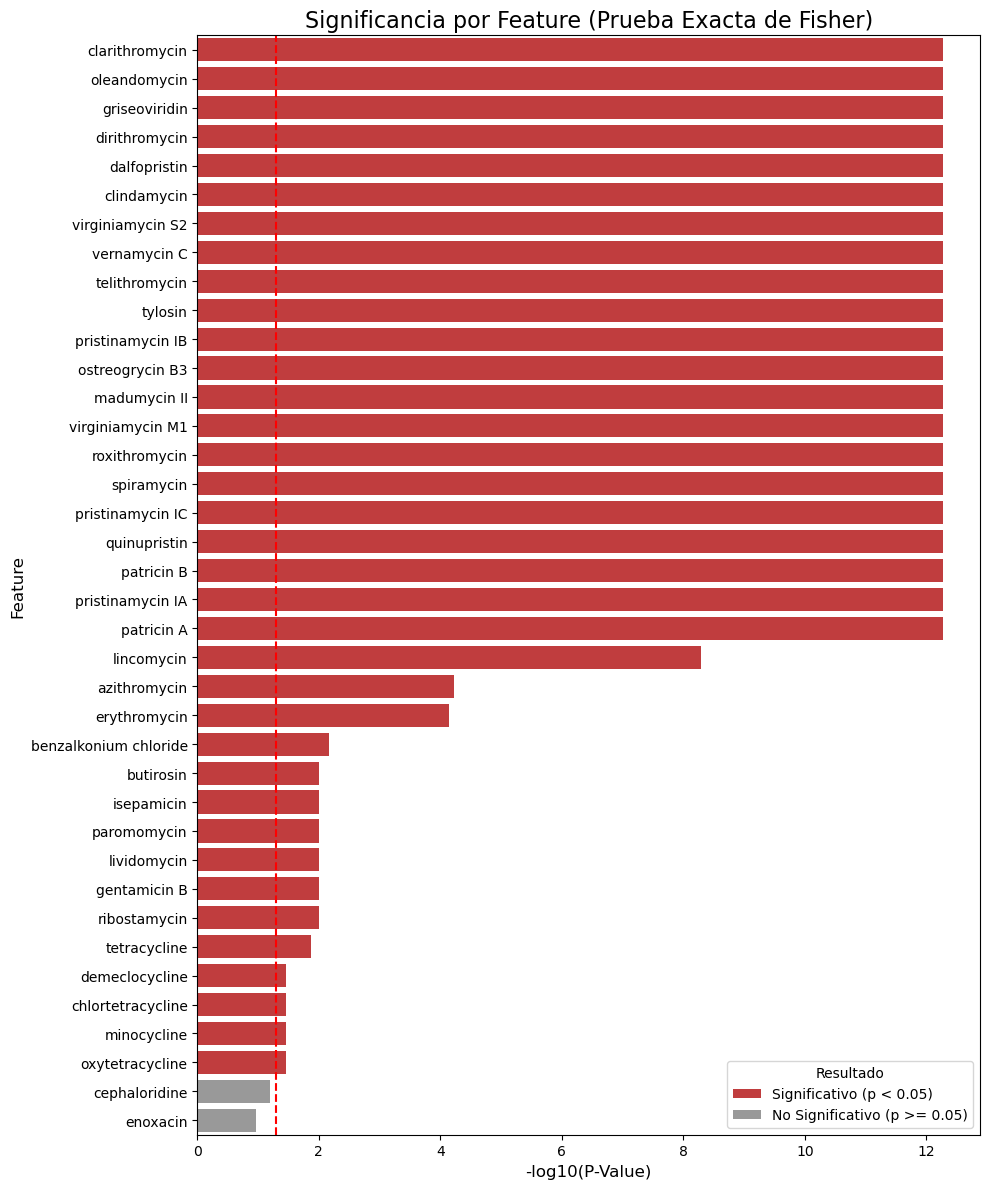

In [45]:
# Copiamos para evitar warnings
plot_df = results_aux.dropna(subset=['p_value_fisher']).copy()

# Manejar p-values de 0 (por si acaso, aunque Fisher no debería dar 0)
plot_df.loc[plot_df['p_value_fisher'] == 0, 'p_value_fisher'] = np.finfo(float).eps

# ¡¡LA CLAVE!! Usar p_value_fisher para el -log10
plot_df['neg_log10_p'] = -np.log10(plot_df['p_value_fisher'])

# Definir el umbral
p_threshold = 0.05
log_threshold = -np.log10(p_threshold)

# ¡LA OTRA CLAVE! Crear una columna para colorear
plot_df['Significativo'] = np.where(
    plot_df['p_value_fisher'] < p_threshold, 
    'Significativo (p < 0.05)', 
    'No Significativo (p >= 0.05)'
)

# Ordenamos por significancia para el gráfico
plot_df_sorted = plot_df.sort_values('neg_log10_p', ascending=False)


# --- 3. Crear el Gráfico Horizontal (Estilo Publicación) ---
plt.figure(figsize=(10, 12)) # Ajusta el tamaño (más alto que ancho)

# ¡VOLTEAMOS EL GRÁFICO! x='neg_log10_p', y='feature'
barplot = sns.barplot(
    x='neg_log10_p', 
    y='feature', 
    data=plot_df_sorted,
    hue='Significativo',    # Usamos 'hue' para los dos colores
    palette={'Significativo (p < 0.05)': '#d62728',  # Rojo fuerte
             'No Significativo (p >= 0.05)': '#999999'}, # Gris
    dodge=False # Evita que las barras se separen
)

# ¡VOLTEAMOS LA LÍNEA! Ahora es una línea vertical (axvline)
plt.axvline(
    x=log_threshold, 
    color='red', 
    linestyle='--', 
    linewidth=1.5,
    # No necesitamos label, lo explicamos en el pie de figura
)

# --- 4. Añadir Títulos y Etiquetas Limpios ---
plt.title('Significancia por Feature (Prueba Exacta de Fisher)', fontsize=16)
plt.xlabel('-log10(P-Value)', fontsize=12)
plt.ylabel('Feature', fontsize=12)

# Mover la leyenda de 'hue' (Significativo/No Significativo)
plt.legend(title='Resultado', loc='lower right')

plt.tight_layout()
plt.show()

In [26]:
results_df.sort_values(by='chi2_stat').tail(20)

,feature,chi2_stat,p_value_chi2,p_value_fisher
39,dirithromycin,48.914264,2.673991e-12,5.393307e-13
35,dalfopristin,48.914264,2.673991e-12,5.393307e-13
62,madumycin II,48.914264,2.673991e-12,5.393307e-13
53,griseoviridin,48.914264,2.673991e-12,5.393307e-13
91,pristinamycin IA,48.914264,2.673991e-12,5.393307e-13
93,pristinamycin IC,48.914264,2.673991e-12,5.393307e-13
82,patricin B,48.914264,2.673991e-12,5.393307e-13
76,oleandomycin,48.914264,2.673991e-12,5.393307e-13
77,ostreogrycin B3,48.914264,2.673991e-12,5.393307e-13
81,patricin A,48.914264,2.673991e-12,5.393307e-13


In [30]:
results_df[results_df['p_value_chi2'] < 0.01]

,feature,chi2_stat,p_value_chi2,p_value_fisher
7,azithromycin,15.250545,9.414960e-05,6.001496e-05
12,benzalkonium chloride,7.146947,7.509172e-03,6.889742e-03
30,clarithromycin,48.914264,2.673991e-12,5.393307e-13
31,clindamycin,48.914264,2.673991e-12,5.393307e-13
35,dalfopristin,48.914264,2.673991e-12,5.393307e-13
39,dirithromycin,48.914264,2.673991e-12,5.393307e-13
44,erythromycin,15.477489,8.349370e-05,7.190188e-05
53,griseoviridin,48.914264,2.673991e-12,5.393307e-13
58,lincomycin,32.692761,1.079385e-08,5.202882e-09
62,madumycin II,48.914264,2.673991e-12,5.393307e-13


In [28]:
results_df[results_df['feature'] == 'rifampin']

,feature,chi2_stat,p_value_chi2,p_value_fisher
98,rifampin,0.96009,0.327164,0.293539


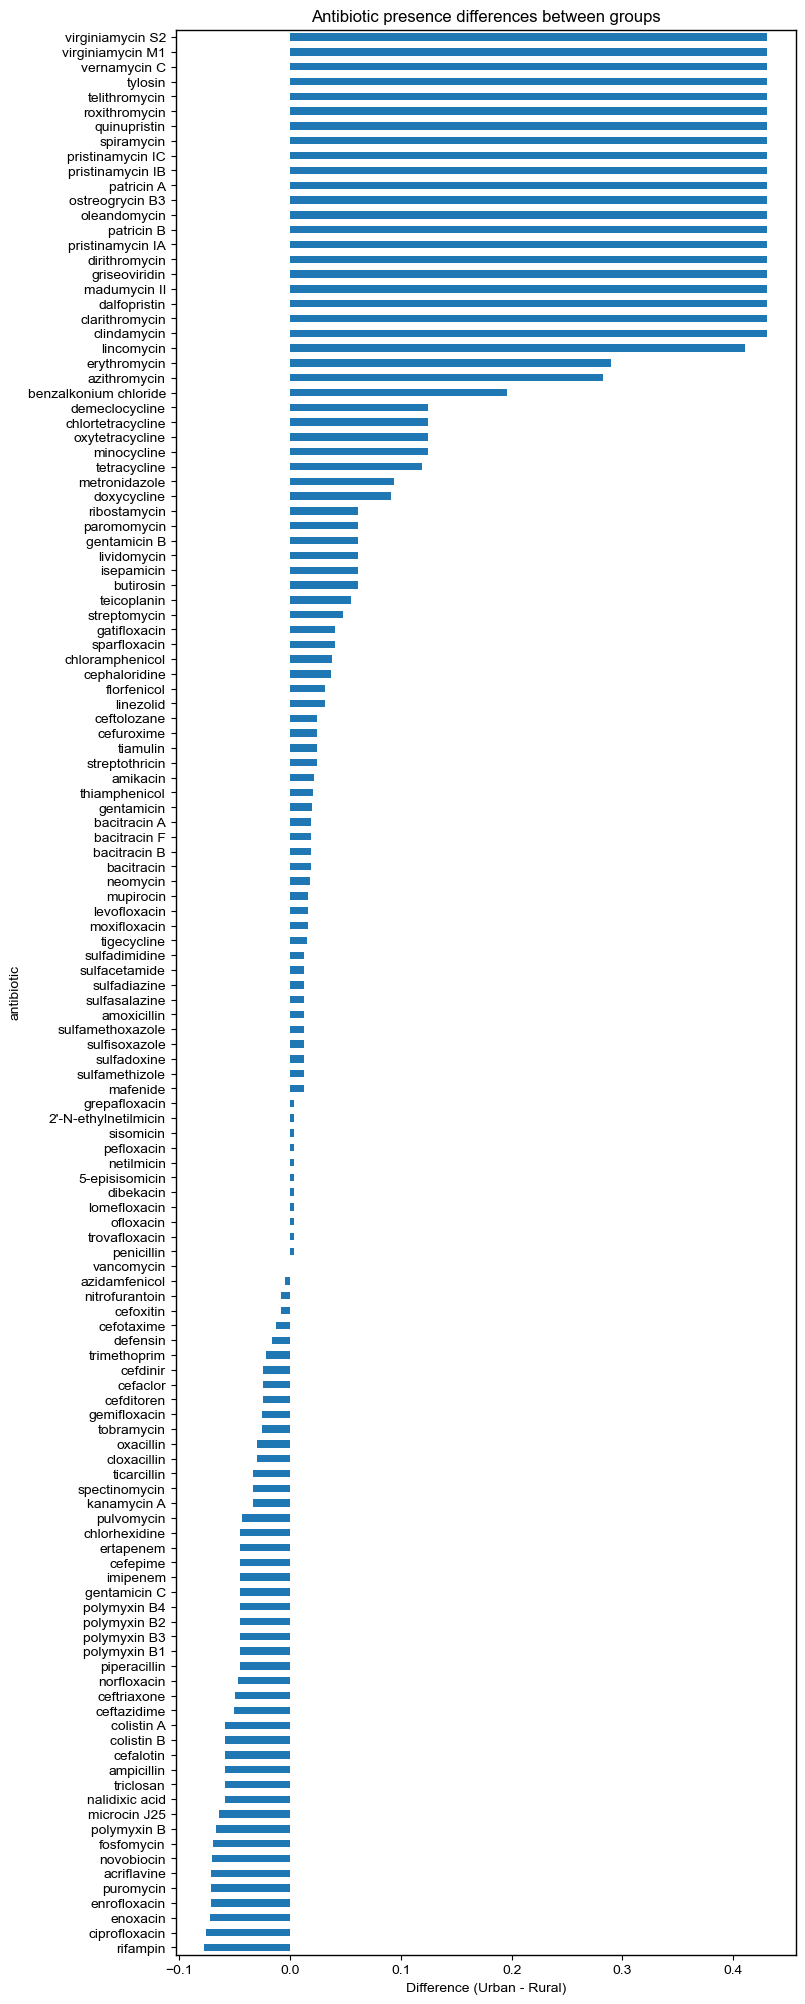

In [77]:
group_means = presence_df.groupby('label').mean().T
group_means['diff'] = group_means['Urban'] - group_means['Rural']
group_means.sort_values('diff', key=abs, ascending=False)
plt.figure(figsize=(8, 25))
group_means['diff'].sort_values().plot(kind='barh')
plt.xlabel('Difference (Urban - Rural)')
plt.title('Antibiotic presence differences between groups')
plt.show()
# print(group_means)

In [17]:
group_means = pd.read_csv('antibiotics_resistance2.csv', index_col = 0)

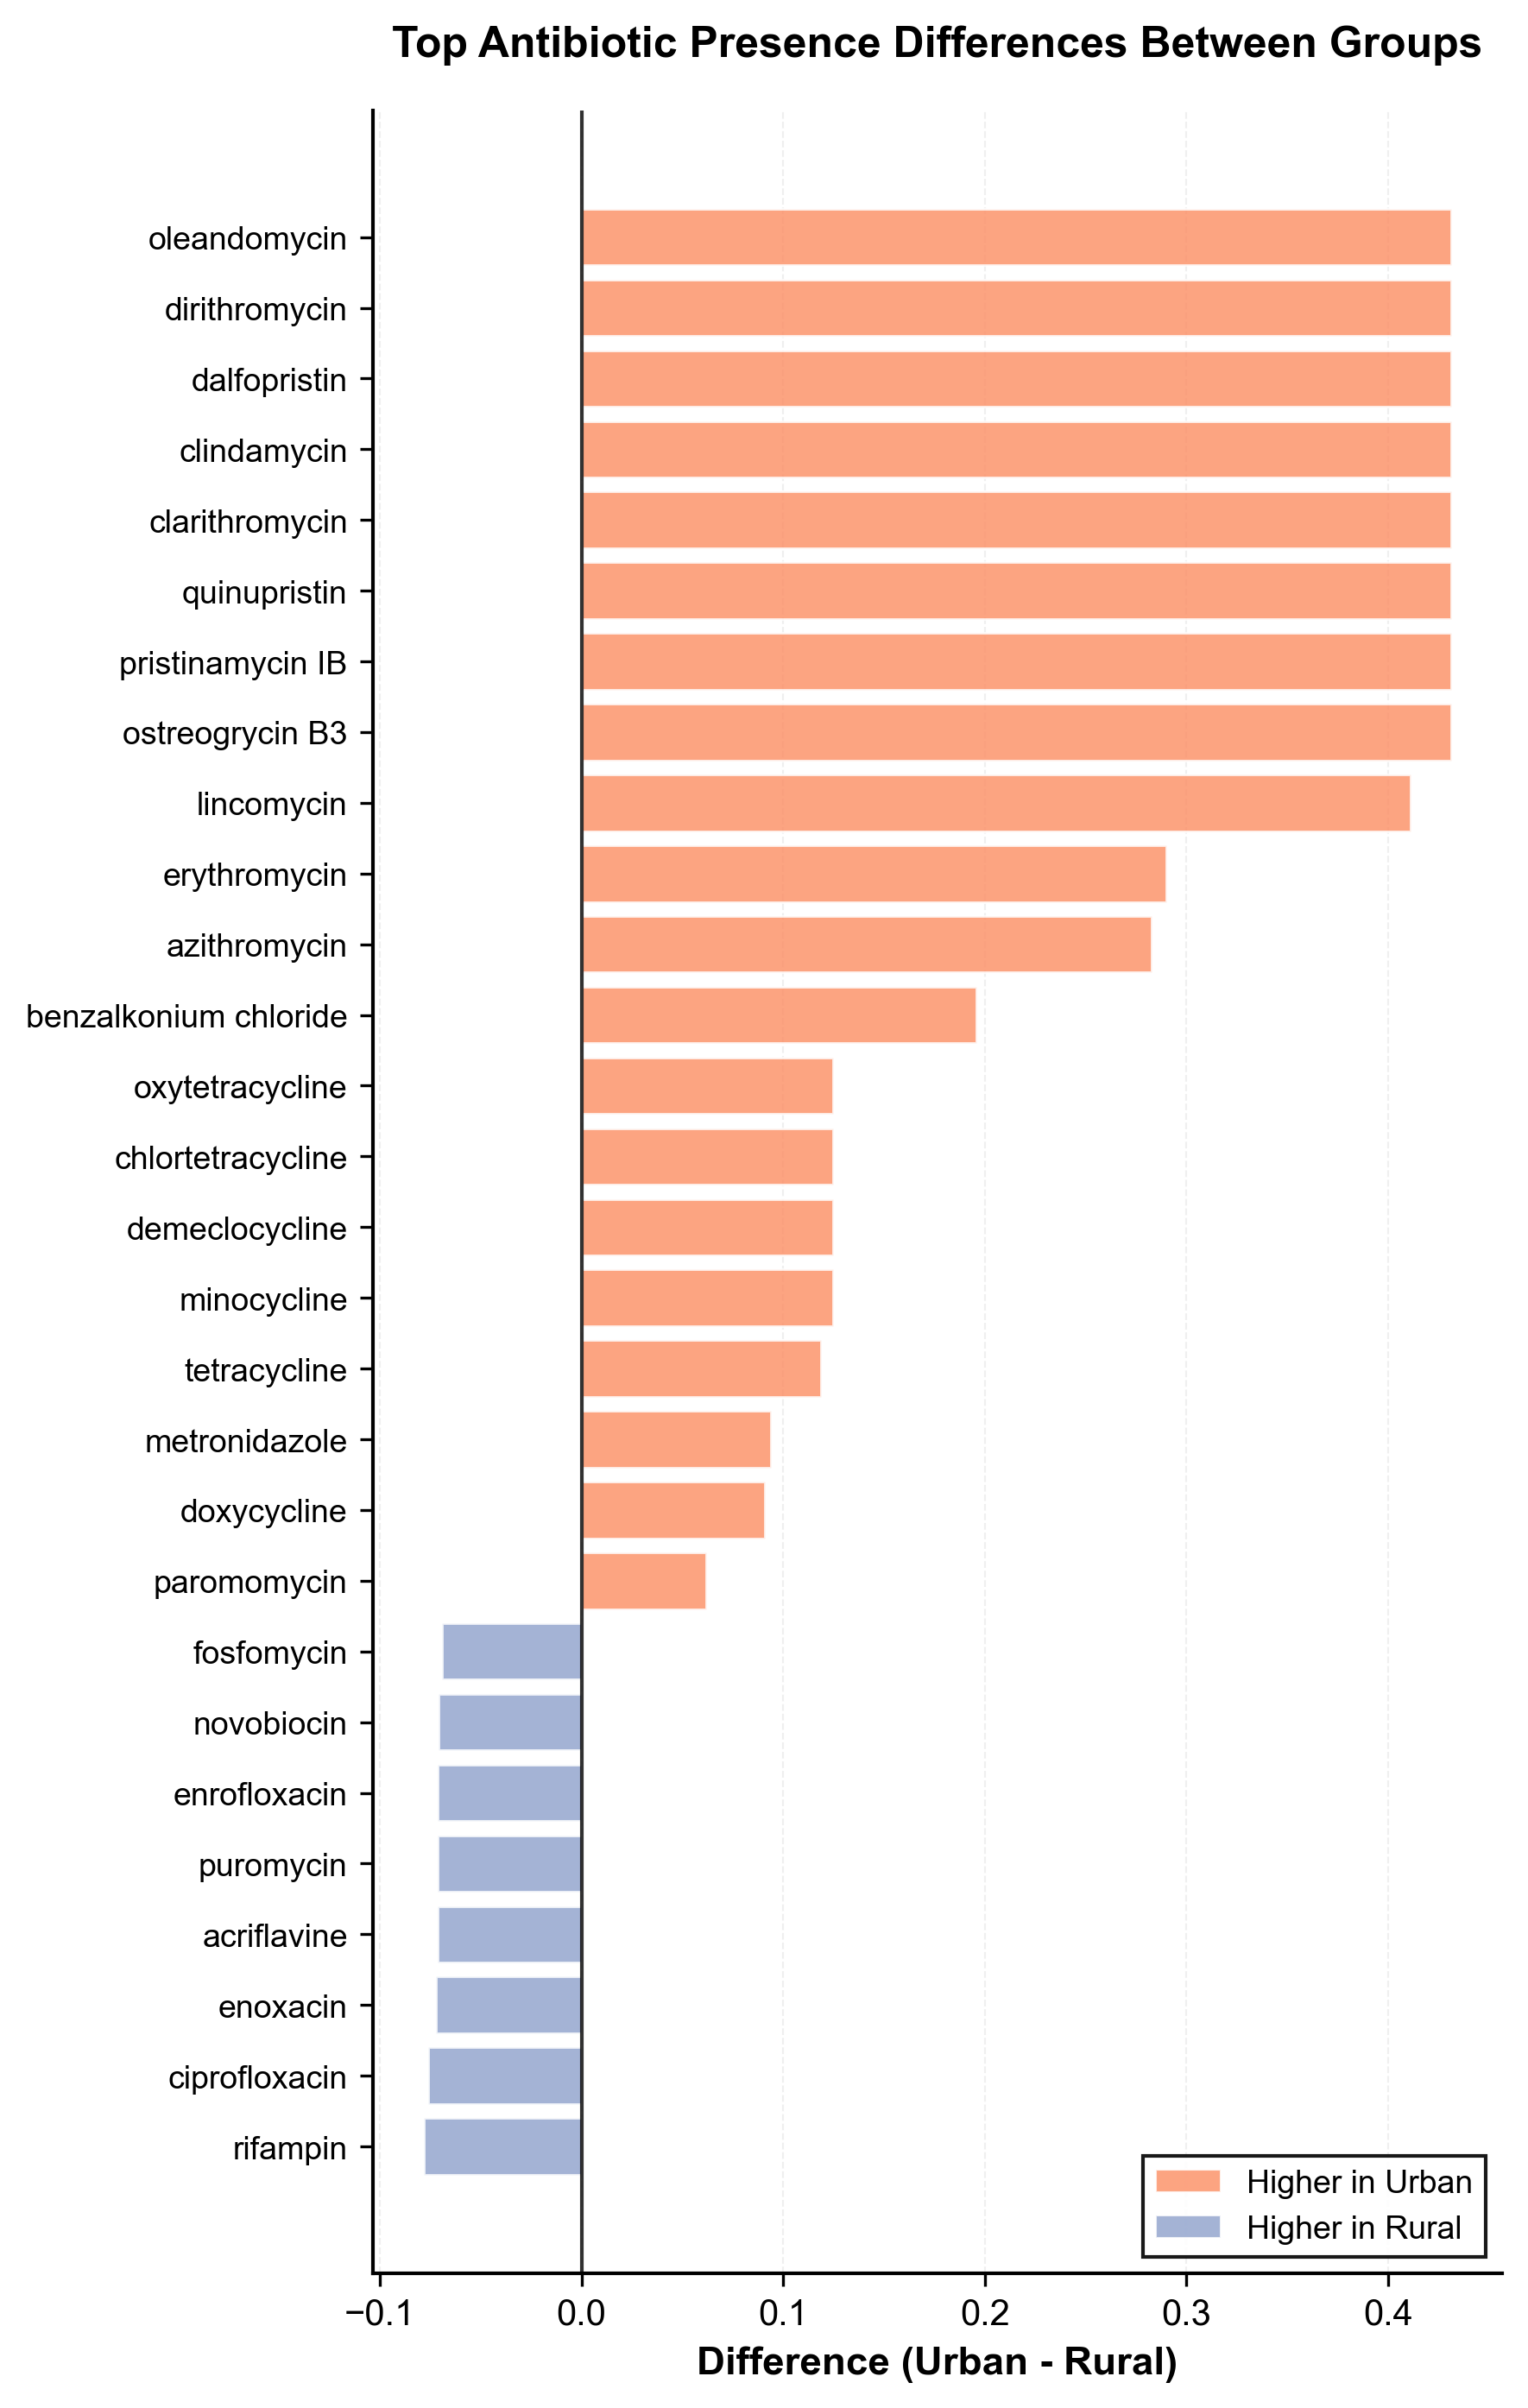

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate group means and differences
# group_means = presence_df.groupby('label').mean().T
group_means['diff'] = group_means['Urban'] - group_means['Rural']

# Filter for differences with absolute value > 0.10
# filtered_means = group_means[np.abs(group_means['diff']) > 0.07].copy()

# Sort by difference
filtered_means_sorted = group_means.sort_values('diff')
filtered_means_sorted = pd.concat([filtered_means_sorted.head(8), filtered_means_sorted.tail(20)])

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0

# Define colors for Urban and Rural
color_urban = plt.cm.Set2.colors[1]  # Orange/coral from Set2
color_rural = plt.cm.Set2.colors[2]  # Green from Set2

# Create colors array: positive = Urban color, negative = Rural color
colors = [color_urban if x > 0 else color_rural for x in filtered_means_sorted['diff']]

# Create figure
fig, ax = plt.subplots(figsize=(6, len(filtered_means_sorted) * 0.3 + 1), dpi=300)

# Create horizontal bar plot
bars = ax.barh(range(len(filtered_means_sorted)), 
               filtered_means_sorted['diff'],
               color=colors,
               alpha=0.8,
               edgecolor='white',
               linewidth=0.7)

# Set y-axis labels
ax.set_yticks(range(len(filtered_means_sorted)))
ax.set_yticklabels(filtered_means_sorted.index, fontsize=9)

# Format axes
ax.set_xlabel('Difference (Urban - Rural)', fontsize=11, fontweight='bold')
ax.set_title('Top Antibiotic Presence Differences Between Groups', 
             fontsize=12, fontweight='bold', pad=15)

# Add vertical line at x=0
ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.8)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, axis='x')
ax.set_axisbelow(True)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_urban, edgecolor='white', linewidth=0.5, label='Higher in Urban', alpha=0.8),
                   Patch(facecolor=color_rural, edgecolor='white', linewidth=0.5, label='Higher in Rural', alpha=0.8)]
ax.legend(handles=legend_elements, 
          loc='lower right',
          frameon=True,
          edgecolor='black',
          fancybox=False,
          framealpha=0.9,
          fontsize=9)

plt.tight_layout()
plt.show()

# Optional: Save figure
# fig.savefig('antibiotic_differences.pdf', dpi=300, bbox_inches='tight')
fig.savefig('antibiotic_differences.png', dpi=400, bbox_inches='tight')

C:\Users\rafap\AppData\Local\Temp\ipykernel_26352\2347088391.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set2')


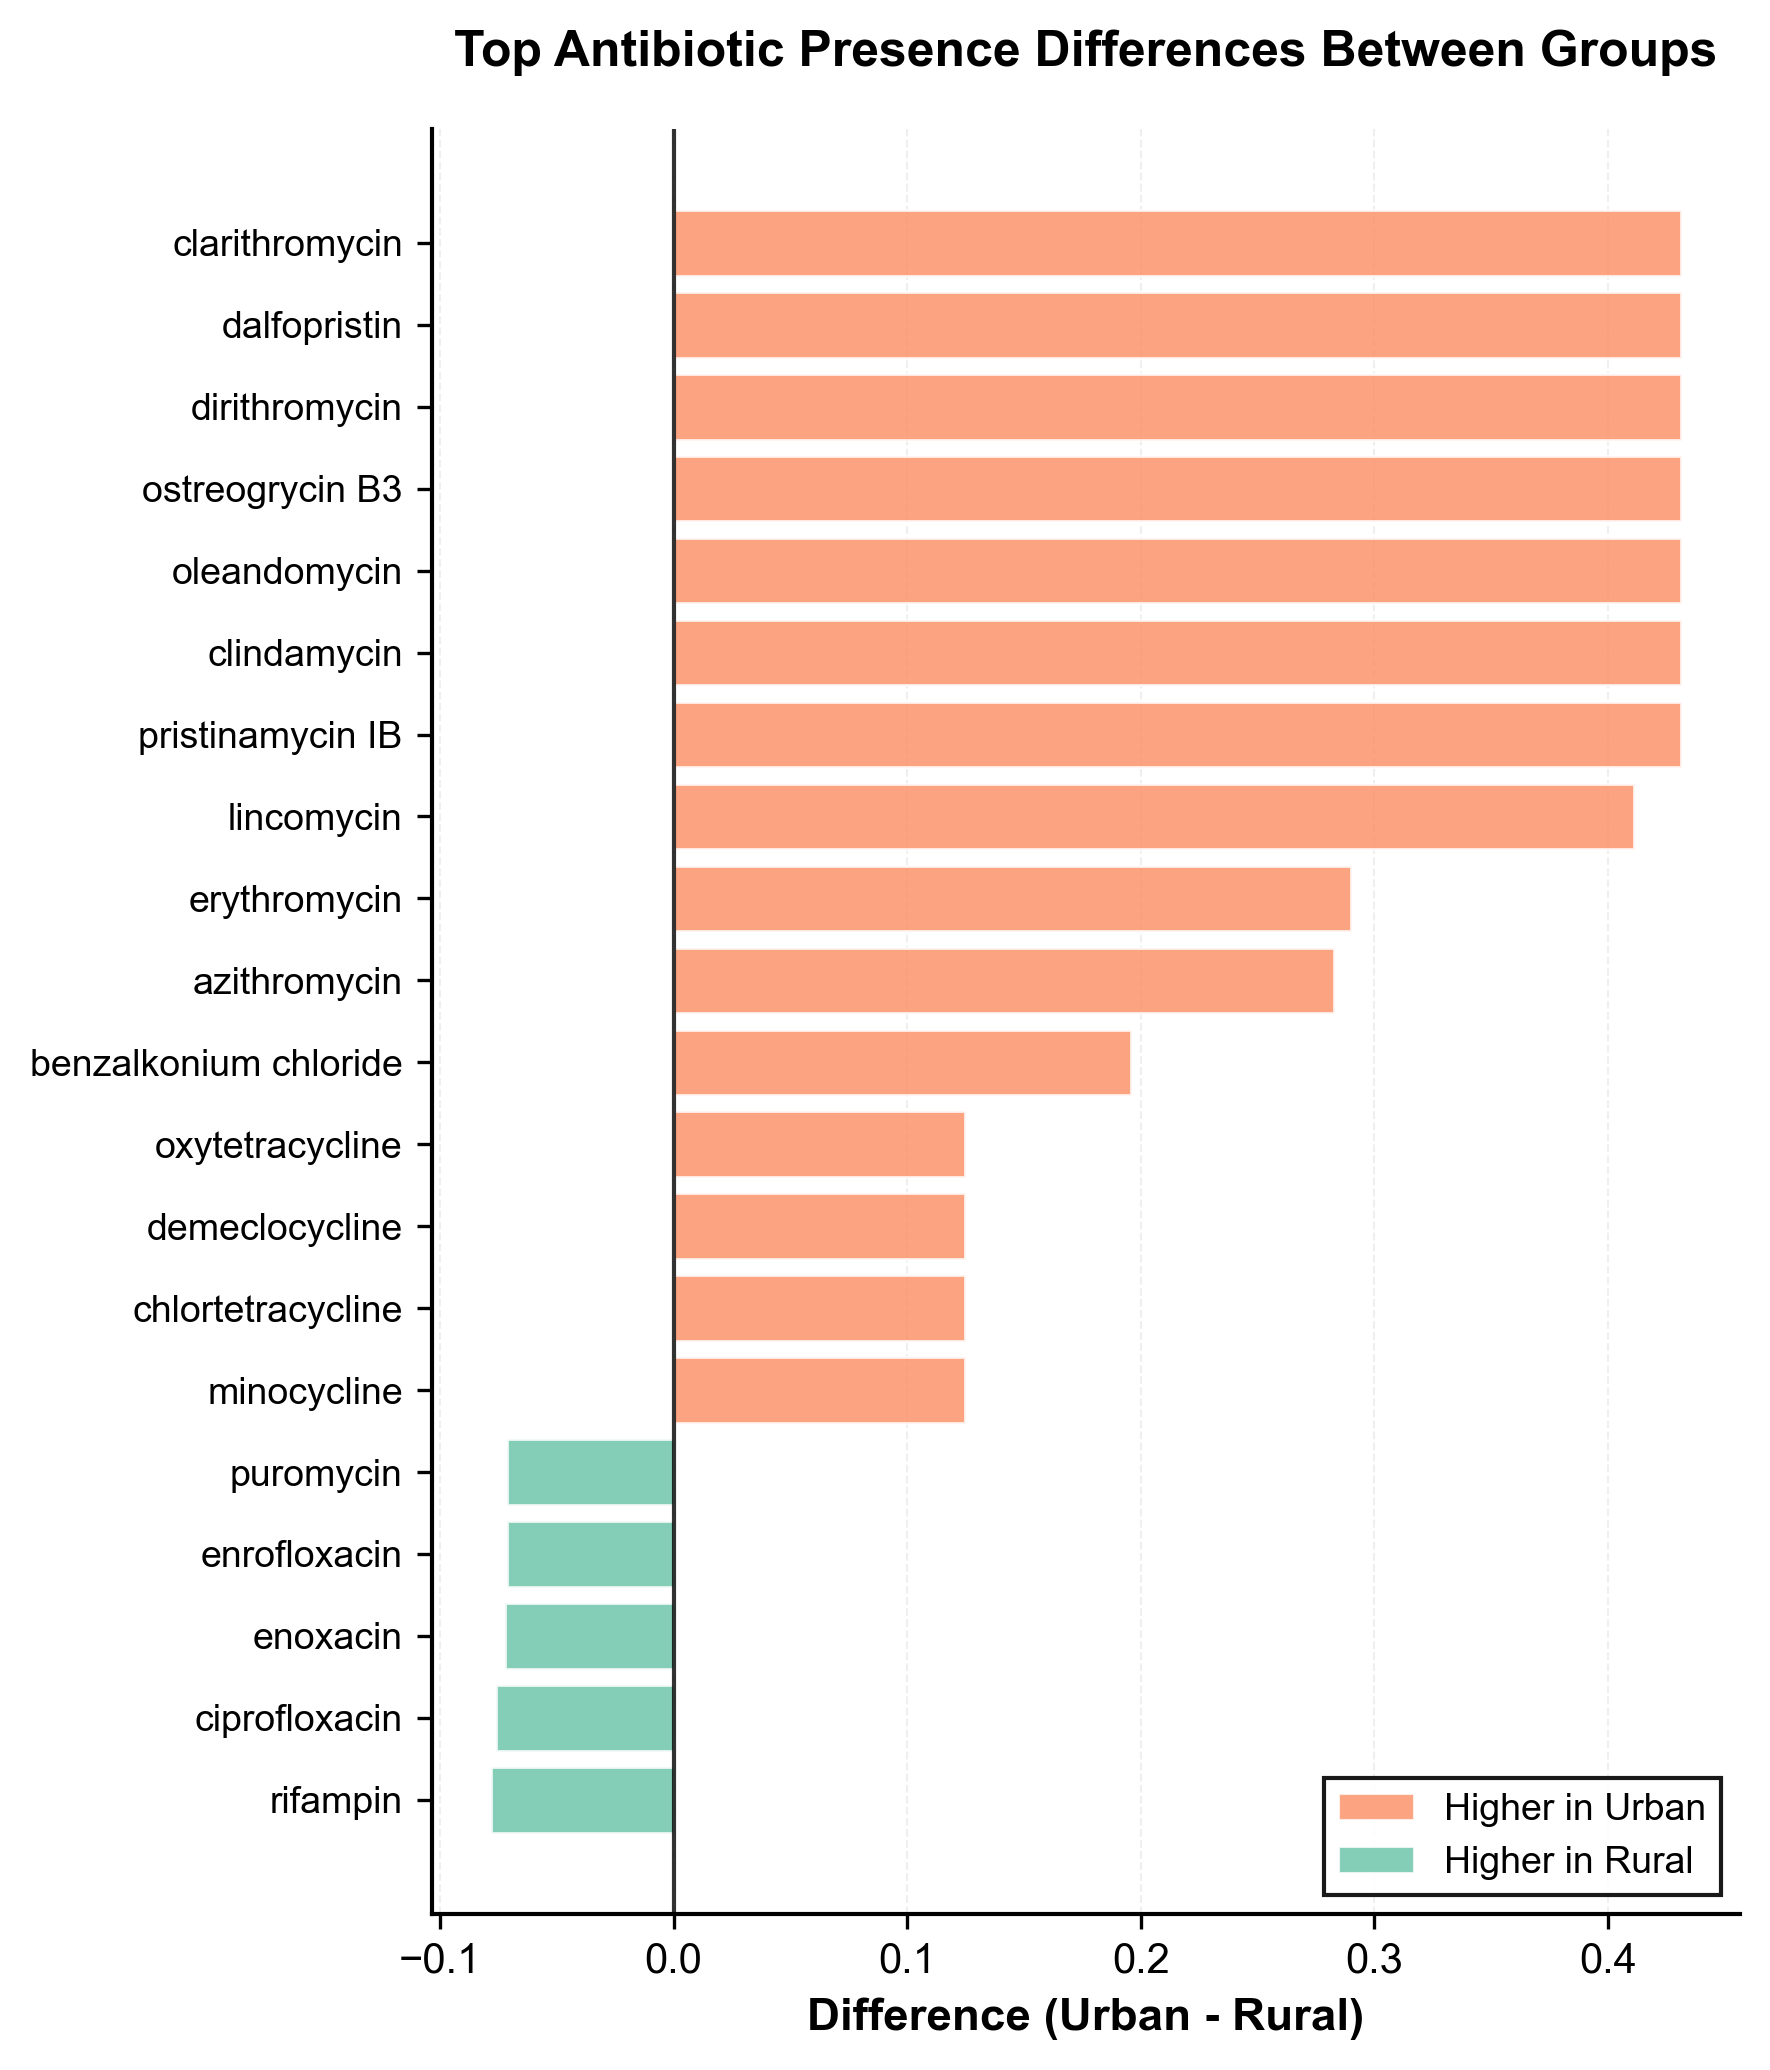

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate group means and differences
group_means['diff'] = group_means['Urban'] - group_means['Rural']

# Sort by difference
filtered_means_sorted = group_means.sort_values('diff')
filtered_means_sorted = pd.concat([filtered_means_sorted.head(5), filtered_means_sorted.tail(15)])

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0

# Define colors for Urban and Rural using Set2 palette (same as working code)
cmap = plt.cm.get_cmap('Set2')
color_urban = cmap.colors[1]   # Orange for Urban (positive = Urban)
color_rural = cmap.colors[0]   # Teal/Green for Rural (negative = Rural)

# Create colors array: positive = Urban color, negative = Rural color
colors = [color_urban if x > 0 else color_rural for x in filtered_means_sorted['diff']]

# Create figure
fig, ax = plt.subplots(figsize=(6, len(filtered_means_sorted) * 0.3 + 1), dpi=300)

# Create horizontal bar plot
bars = ax.barh(range(len(filtered_means_sorted)), 
               filtered_means_sorted['diff'],
               color=colors,
               alpha=0.8,
               edgecolor='white',
               linewidth=0.7)

# Set y-axis labels
ax.set_yticks(range(len(filtered_means_sorted)))
ax.set_yticklabels(filtered_means_sorted.index, fontsize=9)

# Format axes
ax.set_xlabel('Difference (Urban - Rural)', fontsize=11, fontweight='bold')
ax.set_title('Top Antibiotic Presence Differences Between Groups', 
             fontsize=12, fontweight='bold', pad=15)

# Add vertical line at x=0
ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.8)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, axis='x')
ax.set_axisbelow(True)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_urban, edgecolor='white', linewidth=0.5, label='Higher in Urban', alpha=0.8),
                   Patch(facecolor=color_rural, edgecolor='white', linewidth=0.5, label='Higher in Rural', alpha=0.8)]
ax.legend(handles=legend_elements, 
          loc='lower right',
          frameon=True,
          edgecolor='black',
          fancybox=False,
          framealpha=0.9,
          fontsize=9)

plt.tight_layout()
plt.show()

# Save figure
fig.savefig('antibiotic_differences.png', dpi=400, bbox_inches='tight')

In [18]:
# group_means.to_csv('antibiotics_resistance.csv')

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Inicio: Lógica de Agrupación ---

def get_group(antibiotic_name):
    """Asigna un nombre de grupo a un antibiótico basado en palabras clave."""
    name_low = antibiotic_name.lower()
    if 'sulfa' in name_low:
        return 'Sulfonamides (promedio)'
    if 'cillin' in name_low:
        return 'Penicillins (promedio)'
    if 'cycline' in name_low:
        return 'Tetracyclines (promedio)'
    if 'mycin' in name_low: # Agrupa Macrólidos, Aminoglucósidos, etc.
        return 'Grupo ...mycin (promedio)'
    if 'floxacin' in name_low: # Agrupa Quinolonas
        return 'Quinolones (promedio)'
    # Si no pertenece a un grupo, se queda como individual
    return antibiotic_name

# --- Fin: Lógica de Agrupación ---

def create_antibiotic_plot(file_path='antibiotics_resistance.csv', n_items=10):
    """
    Carga los datos, los agrupa, y crea un gráfico de barras horizontales
    mostrando el Top N y Bottom N de las diferencias.
    """
    try:
        # Cargar los datos
        df = pd.read_csv(file_path)

        # 1. Aplicar la función de agrupación
        # df['group'] = df['antibiotic'].apply(get_group)

        # 2. Calcular el promedio de 'diff' para cada grupo
        #    (Los antibióticos individuales tendrán su propio valor como promedio)
        # df_grouped = df.groupby('group')['diff'].mean().reset_index()

        # 3. Renombrar la columna 'group' de nuevo a 'antibiotic' para el plot
        # df_agg = df_grouped.rename(columns={'group': 'antibiotic'})
        
        print(f"Datos originales: {len(df)} antibióticos.")
        print(f"Datos agrupados: {len(df_agg)} items (grupos e individuales).")

        # 4. Obtener el "Top N" (más prevalentes en zona URBANA)
        df_top = df.nlargest(n_items, 'diff')

        # 5. Obtener el "Bottom N" (más prevalentes en zona RURAL)
        df_bottom = df_agg.nsmallest(n_items, 'diff')

        # 6. Combinar los dos grupos
        df_plot = pd.concat([df_top, df_bottom]).drop_duplicates()

        # 7. Ordenar para el gráfico (de más rural a más urbano)
        df_plot = df_plot.sort_values(by='diff', ascending=True)

        # 8. Definir los colores (Paleta "Set2" invertida)
        cmap = plt.cm.get_cmap('Set2')
        # Positivo (Urbano) = Naranja (índice 1 de la paleta)
        color_positive = cmap.colors[1] 
        # Negativo (Rural) = Verde (índice 0 de la paleta)
        color_negative = cmap.colors[0] 

        colors_for_plot = [color_positive if x > 0 else color_negative for x in df_plot['diff']]

        # 9. Crear el gráfico
        num_items_total = len(df_plot)
        # Ajustar la altura dinámicamente
        fig_height = max(10, num_items_total * 0.45 + 2) 
        
        plt.figure(figsize=(12, fig_height))
        
        plt.barh(df_plot['antibiotic'], df_plot['diff'], color=colors_for_plot)

        # 10. Añadir detalles al gráfico
        plt.axvline(x=0, color='grey', linestyle='--')
        plt.xlabel('Diferencia en prevalencia (Proporción Urbana - Proporción Rural)')
        plt.ylabel('Antibiótico o Grupo (promedio)')
        plt.title(f'Top {n_items} (Más Urbanos) y Bottom {n_items} (Más Rurales) por Diferencia (Agrupados)')
        
        # Ajustar el diseño para que no se corten las etiquetas
        plt.tight_layout()

        # 11. Guardar el gráfico
        output_filename = f'grouped_top_bottom_{n_items}_inverted_set2.png'
        plt.savefig(output_filename)

        print(f"\n¡Gráfico guardado exitosamente como: {output_filename}!")
        print(f"Mostrando {num_items_total} items en total.")

    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{file_path}'.")
        print("Por favor, asegúrate de que el archivo esté en el mismo directorio que el script.")
    except Exception as e:
        print(f"Ocurrió un error inesperado: {e}")


In [14]:
create_antibiotic_plot(file_path='antibiotics_resistance2.csv', n_items=10)

Datos originales: 117 antibióticos.
Ocurrió un error inesperado: name 'df_agg' is not defined
